In [550]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

import torch
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import torch.utils.data as data


In [551]:
# device = torch.device("cuda")
device = torch.device("cpu")
# set_seed(42)

In [552]:
target_discrete_intervals = torch.tensor([100000, 350000]) # 0 to mniej niż 100k$, 1 pomiędzy, 2 więcej
validation_percent = 0.3 # Ile w walidacyjnym

categorical_columns = ["HallwayType", "HeatingType", "AptManageType", "TimeToBusStop", "TimeToSubway", "SubwayStation"]
columns_to_drop = []

### Ładowanie danych


Warto zparametryzować batch_size

Pewnie są dodatkowe parametry w data.DataLoader(...) które mogą nam pomóc


In [553]:
def Get_Train_Data():
    train_data = pd.read_csv("train_data.csv")
    train_data = train_data.drop(columns=columns_to_drop)
    return train_data

def Get_Train_Values(train_data):
    train_categorical = pd.get_dummies(train_data[categorical_columns]).astype(int)
    train_numerical = train_data.drop(columns=categorical_columns)
    return train_numerical, train_categorical


In [554]:
def Get_Final_Test_Data():
    final_test_data = pd.read_csv("test_data.csv", index_col=None)
    final_test_data = final_test_data.drop(columns=columns_to_drop)

    return final_test_data

In [555]:
def Get_Final_Test_Values(final_test_data):
    final_test_categorical = pd.get_dummies(final_test_data[categorical_columns]).astype(int)
    final_test_numerical = final_test_data.drop(columns=categorical_columns)
    return final_test_numerical, final_test_categorical

In [556]:
from matplotlib.pylab import size


def Get_Train_And_Validate_Loaders(train_numerical, train_categorical, size):
    train_indices = np.random.rand(size)>validation_percent
    print("Train data size: ", size)

    numerical_data = torch.from_numpy(train_numerical.values[train_indices, 1:]).float()
    categorical_data = torch.from_numpy(train_categorical.values[train_indices]).float()
    numerical_train_targets = torch.from_numpy(train_numerical.values[train_indices, 0]).float()
    discrete_train_targets = torch.bucketize(numerical_train_targets, target_discrete_intervals) # Dyskretne etykiety

    print(numerical_data.shape)
    print(categorical_data.shape)
    print(discrete_train_targets.shape)

    validate_numerical_data = torch.from_numpy(train_numerical.values[~train_indices, 1:]).float()
    validate_categorical_data = torch.from_numpy(train_categorical.values[~train_indices]).float()
    numerical_validate_targets = torch.from_numpy(train_numerical.values[~train_indices, 0]).float()
    discrete_validate_targets = torch.bucketize(numerical_validate_targets, target_discrete_intervals) # Dyskretne etykiety

    train_dataset = data.TensorDataset(numerical_data, categorical_data, discrete_train_targets)
    validate_dataset = data.TensorDataset(validate_numerical_data, validate_categorical_data, discrete_validate_targets)

    train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    validate_loader = data.DataLoader(validate_dataset, batch_size=32, shuffle=False)
    if validation_percent == 0:
        return train_loader, None

    return train_loader, validate_loader

In [557]:
def Get_Final_Test_Loader(final_test_numerical, final_test_categorical, size):
    print("Final test data size: ", size)

    final_test_numerical_data = torch.from_numpy(final_test_numerical.values).float()
    final_test_categorical_data = torch.from_numpy(final_test_categorical.values).float()

    final_test_dataset = data.TensorDataset(final_test_numerical_data, final_test_categorical_data)
    final_test_loader = data.DataLoader(final_test_dataset, shuffle=False)

    return final_test_loader

### Liczenie dokładności

In [558]:
def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct=(pred_targets.squeeze() == targets)[targets == i].sum() # tu zmieniłem żeby z tensorami działało
        accuracies.append(class_correct/(targets == i).sum())
    return(np.mean(accuracies))

In [559]:
def Get_Accuracy(model, data_loader, get_output_distribution=False):
    model.eval()
    guesses_distribution = np.zeros(3, dtype=np.int64)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, cat_x, labels in data_loader:
            x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)

            output = model(x, cat_x)
            if output.ndim == 1:
                output = output.unsqueeze(0)

            pred_ = output.argmax(dim=1)
            labels = labels.view(-1).long()

            all_preds.append(pred_)
            all_targets.append(labels)

            guesses_distribution += torch.bincount(pred_, minlength=3).cpu().numpy()

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    accuracy = calc_accuracy(all_preds, all_targets)
    if get_output_distribution:
        return accuracy, guesses_distribution
    return accuracy

#### Zapis do pliku


In [560]:
def Save_Final_Predictions_To_File(model, final_test_loader):
    model.eval()
    output_array = []
    with torch.no_grad():
        for x, cat_x in final_test_loader:
            x, cat_x = x.to(device), cat_x.to(device)
            # x = x.unsqueeze(0)
            # cat_x = cat_x.unsqueeze(0)

            out = model(x, cat_x).squeeze()
            pred_ = out.max(0, keepdim=True)[1]
            output_array.append(pred_.item())

    pd.Series(output_array).to_csv("pred.csv", index=False, header=False)


### Tworzenie DataLoaderów


In [561]:
train_data = Get_Train_Data()
train_numerical_values, train_categorical_values = Get_Train_Values(train_data)
train_loader, validate_loader = Get_Train_And_Validate_Loaders(train_numerical_values, train_categorical_values, len(train_data))

final_test_data= Get_Final_Test_Data()
final_test_numerical_values, final_test_categorical_values = Get_Final_Test_Values(final_test_data)
final_test_loader = Get_Final_Test_Loader(final_test_numerical_values, final_test_categorical_values, len(final_test_data))

Train data size:  4124
torch.Size([2904, 10])
torch.Size([2904, 23])
torch.Size([2904])
Final test data size:  1767


#### Badanie rozkładu klas


In [562]:
def Get_Class_Weights(weight_classes : bool):
    if not weight_classes:
        return torch.ones(size=[len(target_discrete_intervals)+1])
    check_train_data = Get_Train_Data()
    check_num, _ = Get_Train_Values(check_train_data)
    check_numerical_train_targets = torch.from_numpy(check_num.values[:, 0]).float()
    check_discrete_train_targets = torch.bucketize(check_numerical_train_targets, target_discrete_intervals) # Dyskretne etykiety
    check_out_dist = torch.nn.functional.one_hot(check_discrete_train_targets).sum(dim=0)
    print("Class distribution: ", check_out_dist)
    class_weights = torch.tensor([1.0/check_out_dist[0], 1.0/check_out_dist[1], 1.0/check_out_dist[2]])
    class_weights = class_weights / class_weights.sum()
    print(class_weights)
    return class_weights

Get_Class_Weights(True)

Class distribution:  tensor([ 562, 2992,  570])
tensor([0.4600, 0.0864, 0.4536])


tensor([0.4600, 0.0864, 0.4536])

In [563]:
input_size = train_numerical_values.shape[1] + train_categorical_values.shape[1] - 1
print(input_size)

33


### Trenowanie


In [564]:
class Price_classifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 40)
        self.norm1  = nn.LayerNorm(40)
        self.act_1  = nn.LeakyReLU()
        self.d1     = nn.Dropout(0.4)

        self.layer2 = nn.Linear(40, 20)
        self.norm2  = nn.LayerNorm(20)
        self.act_2  = nn.LeakyReLU()
        self.d2     = nn.Dropout(0.4)

        self.layer3 = nn.Linear(20, 3)

    def forward(self, x, cat_x):
        x = torch.cat([x, cat_x], dim=1)

        x = self.layer1(x)
        x = self.norm1(x)
        x = self.act_1(x)
        x = self.d1(x)

        x = self.layer2(x)
        x = self.norm2(x)
        x = self.act_2(x)
        x = self.d2(x)

        out = self.layer3(x)
        return out

In [565]:
# criterion = nn.CrossEntropyLoss()
# model = Price_classifier(input_size).to(device)
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

# iters = []
# losses = []
# train_acc = []
# val_acc = []
# for n in range(100):
#     epoch_losses = []
#     model.train()
#     for x, cat_x, labels in iter(train_loader):
#         optimizer.zero_grad()
#         x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
#         out = model(x, cat_x)
#         loss = criterion(out, labels)
#         loss.backward()
#         epoch_losses.append(loss.item())
#         optimizer.step()

#     loss_mean = np.array(epoch_losses).mean()
#     iters.append(n)
#     losses.append(loss_mean)
#     test_acc = Get_Accuracy(model, validate_loader)
#     print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")

#     train_acc.append(Get_Accuracy(model, train_loader)) # compute training accuracy
#     val_acc.append(test_acc)  # compute validation accuracy


# print("Final Training Accuracy: {}".format(train_acc[-1]))
# print("Final Validation Accuracy: {}".format(val_acc[-1]))

In [566]:
def train(model,
          train_loader,
          validate_loader,
          device,
          num_epochs=100,
          lr=1e-3,
          weight_decay=1e-3,
          log_every=10,
          weight_classes=True,
          with_plot=True
          ):

    criterion = nn.CrossEntropyLoss(weight=Get_Class_Weights(weight_classes))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    iters, losses, train_acc, val_acc = [], [], [], []
    idx = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        for x, cat_x, labels in iter(train_loader):
            x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(x, cat_x)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

            if idx % log_every == log_every - 1:
                iters.append(idx)
                losses.append(float(loss.item()))
                train_acc.append(Get_Accuracy(model, train_loader))

                if validate_loader is not None:
                    val_acc.append(Get_Accuracy(model, validate_loader))

                # val_acc.append(Get_Accuracy(model, validate_loader))
            idx += 1

        loss_mean = float(np.mean(epoch_losses)) if len(epoch_losses) else float("nan")
        if validate_loader is not None and len(val_acc):
            print(f"Epoch {epoch} loss {loss_mean:.3f} val_acc: {val_acc[-1]:.3f}")
        else:
            print(f"Epoch {epoch} loss {loss_mean:.3f}")


    output_distribution = None
    if validate_loader is not None:
        _, output_distribution = Get_Accuracy(model, validate_loader, get_output_distribution=True)

    if with_plot and len(iters):
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.title("Training Curve")
        plt.plot(iters, losses, label="Train")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")

        plt.subplot(1, 2, 2)
        plt.title("Training Curve")
        plt.plot(iters, train_acc, label="Train")
        plt.plot(iters, val_acc, label="Validation")
        plt.xlabel("Iterations")
        plt.ylabel("Training Accuracy")
        plt.legend(loc="best")

        plt.show()

        if output_distribution is not None:
            hist_distribution = np.repeat(np.arange(len(output_distribution)), output_distribution.astype(int))
            plt.hist(hist_distribution)
            plt.title("Output distribution (validation)")
            plt.xlabel("Classes")
            plt.ylabel("Occurences")
            plt.show()

    print("Final Training Accuracy: {}".format(train_acc[-1] if len(train_acc) else None))
    if validate_loader is not None:
        print("Final Validation Accuracy: {}".format(val_acc[-1] if len(val_acc) else None))
        print("Output distribution: ", output_distribution)

    return {
        "iters": iters,
        "losses": losses,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "model": model,
        "optimizer": optimizer,
        "criterion": criterion,
        "output_distribution": output_distribution,
    }


Class distribution:  tensor([ 562, 2992,  570])
tensor([0.4600, 0.0864, 0.4536])
Epoch 0 loss 0.947
Epoch 1 loss 0.607 val_acc: 0.731
Epoch 2 loss 0.529 val_acc: 0.814
Epoch 3 loss 0.508 val_acc: 0.832
Epoch 4 loss 0.517 val_acc: 0.830
Epoch 5 loss 0.497 val_acc: 0.828
Epoch 6 loss 0.505 val_acc: 0.820
Epoch 7 loss 0.508 val_acc: 0.821
Epoch 8 loss 0.513 val_acc: 0.840
Epoch 9 loss 0.524 val_acc: 0.828
Epoch 10 loss 0.506 val_acc: 0.839
Epoch 11 loss 0.514 val_acc: 0.839
Epoch 12 loss 0.414 val_acc: 0.828
Epoch 13 loss 0.413 val_acc: 0.840
Epoch 14 loss 0.430 val_acc: 0.837
Epoch 15 loss 0.430 val_acc: 0.838
Epoch 16 loss 0.437 val_acc: 0.829
Epoch 17 loss 0.440 val_acc: 0.835
Epoch 18 loss 0.469 val_acc: 0.835
Epoch 19 loss 0.446 val_acc: 0.834
Epoch 20 loss 0.468 val_acc: 0.835
Epoch 21 loss 0.470 val_acc: 0.837
Epoch 22 loss 0.480 val_acc: 0.837
Epoch 23 loss 0.396 val_acc: 0.836
Epoch 24 loss 0.400 val_acc: 0.840
Epoch 25 loss 0.402 val_acc: 0.841
Epoch 26 loss 0.410 val_acc: 0.839

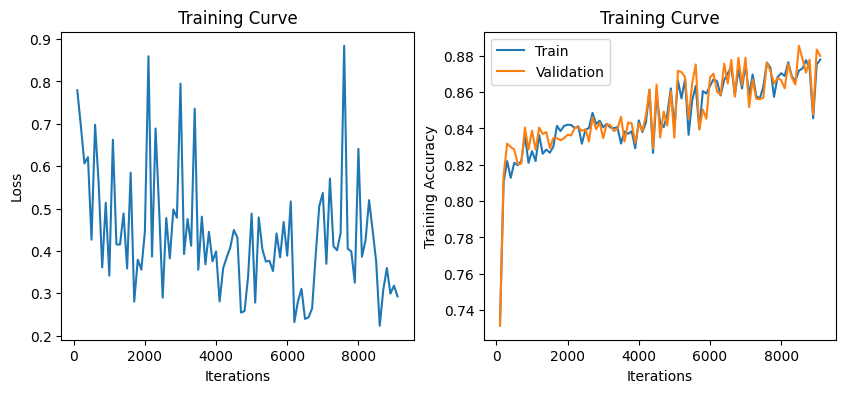

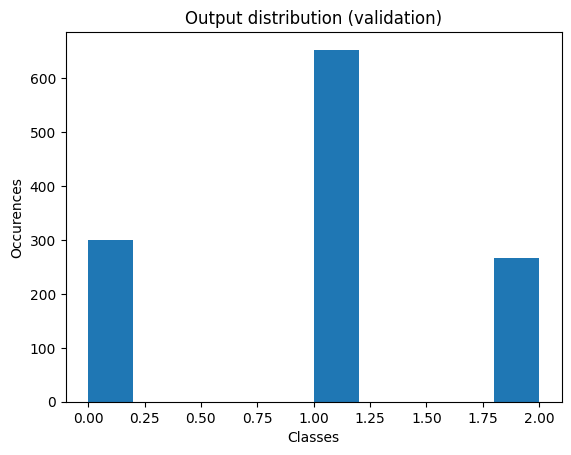

Final Training Accuracy: 0.8778954148292542
Final Validation Accuracy: 0.8799359798431396
Output distribution:  [300 653 267]


In [567]:
model = Price_classifier(input_size).to(device)

history = train(
    model=model,
    train_loader=train_loader,
    validate_loader=validate_loader,
    device=device,
    num_epochs=100,
    lr=0.001,
    weight_decay=0.0001,
    log_every=100,
    weight_classes=True,
    with_plot=True)


### Looking for best parameters

In [ ]:
validation_percent = 0.3 # Ile w walidacyjnym

train_data = Get_Train_Data()
train_numerical_values, train_categorical_values = Get_Train_Values(train_data)
train_loader, validate_loader = Get_Train_And_Validate_Loaders(train_numerical_values, train_categorical_values, len(train_data))

# Do sprawdzenia
lrs = [0.01, 0.001, 0.0001]
num_epochs_list = [50, 100]
weight_decays = [0.0, 0.0001, 0.001]
weight_classes_options = [True, False]

results = []

for lr, num_epochs, weight_decay, weight_classes in product(lrs, num_epochs_list, weight_decays, weight_classes_options):
    print(f"Testuję: lr={lr}, num_epochs={num_epochs}, weight_decay={weight_decay}, weight_classes={weight_classes}")
    model = Price_classifier(input_size).to(device)
    history = train(
        model=model,
        train_loader=train_loader,
        validate_loader=validate_loader,
        device=device,
        num_epochs=num_epochs,
        lr=lr,
        weight_decay=weight_decay,
        log_every=100,
        weight_classes=weight_classes,
        with_plot=False
    )

    val_acc = history['val_acc'][-1] if history['val_acc'] else None
    results.append({
        'lr': lr,
        'num_epochs': num_epochs,
        'weight_decay': weight_decay,
        'weight_classes': weight_classes,
        'val_acc': val_acc
    })

results = sorted(results, key=lambda x: x['val_acc'] if x['val_acc'] is not None else 0, reverse=True)
for res in results:
    print(res)

# {'lr': 0.001, 'num_epochs': 100, 'weight_decay': 0.0001, 'weight_classes': True, 'val_acc': 0.88667446}
# {'lr': 0.01, 'num_epochs': 100, 'weight_decay': 0.0, 'weight_classes': True, 'val_acc': 0.87903124}
# {'lr': 0.001, 'num_epochs': 100, 'weight_decay': 0.001, 'weight_classes': True, 'val_acc': 0.87182}
# {'lr': 0.001, 'num_epochs': 100, 'weight_decay': 0.0, 'weight_classes': True, 'val_acc': 0.8668458}
# {'lr': 0.001, 'num_epochs': 50, 'weight_decay': 0.001, 'weight_classes': True, 'val_acc': 0.86495227}
# {'lr': 0.001, 'num_epochs': 50, 'weight_decay': 0.0, 'weight_classes': True, 'val_acc': 0.86478215}
# {'lr': 0.001, 'num_epochs': 50, 'weight_decay': 0.0001, 'weight_classes': True, 'val_acc': 0.8561533}
# {'lr': 0.0001, 'num_epochs': 100, 'weight_decay': 0.0001, 'weight_classes': True, 'val_acc': 0.8544052}
# {'lr': 0.0001, 'num_epochs': 50, 'weight_decay': 0.001, 'weight_classes': True, 'val_acc': 0.85423994}
# {'lr': 0.0001, 'num_epochs': 100, 'weight_decay': 0.001, 'weight_classes': True, 'val_acc': 0.8480721}
# {'lr': 0.01, 'num_epochs': 100, 'weight_decay': 0.0001, 'weight_classes': True, 'val_acc': 0.8402119}
# {'lr': 0.01, 'num_epochs': 100, 'weight_decay': 0.001, 'weight_classes': True, 'val_acc': 0.83851963}
# {'lr': 0.0001, 'num_epochs': 100, 'weight_decay': 0.0001, 'weight_classes': False, 'val_acc': 0.83812493}
# {'lr': 0.0001, 'num_epochs': 100, 'weight_decay': 0.0, 'weight_classes': True, 'val_acc': 0.8364389}
# {'lr': 0.0001, 'num_epochs': 50, 'weight_decay': 0.0, 'weight_classes': True, 'val_acc': 0.8348045}
# {'lr': 0.01, 'num_epochs': 50, 'weight_decay': 0.0, 'weight_classes': True, 'val_acc': 0.8340833}
# {'lr': 0.0001, 'num_epochs': 50, 'weight_decay': 0.0001, 'weight_classes': True, 'val_acc': 0.8318517}
# {'lr': 0.01, 'num_epochs': 50, 'weight_decay': 0.0001, 'weight_classes': True, 'val_acc': 0.8263286}
# {'lr': 0.01, 'num_epochs': 50, 'weight_decay': 0.001, 'weight_classes': True, 'val_acc': 0.8196772}
# {'lr': 0.001, 'num_epochs': 100, 'weight_decay': 0.0, 'weight_classes': False, 'val_acc': 0.81627697}
# {'lr': 0.001, 'num_epochs': 100, 'weight_decay': 0.001, 'weight_classes': False, 'val_acc': 0.81141704}
# {'lr': 0.001, 'num_epochs': 50, 'weight_decay': 0.0001, 'weight_classes': False, 'val_acc': 0.81137013}
# {'lr': 0.01, 'num_epochs': 50, 'weight_decay': 0.0, 'weight_classes': False, 'val_acc': 0.805669}
# {'lr': 0.001, 'num_epochs': 50, 'weight_decay': 0.0, 'weight_classes': False, 'val_acc': 0.80420214}
# {'lr': 0.0001, 'num_epochs': 100, 'weight_decay': 0.001, 'weight_classes': False, 'val_acc': 0.79995126}
# {'lr': 0.001, 'num_epochs': 50, 'weight_decay': 0.001, 'weight_classes': False, 'val_acc': 0.7901547}
# {'lr': 0.0001, 'num_epochs': 50, 'weight_decay': 0.001, 'weight_classes': False, 'val_acc': 0.7647795}
# {'lr': 0.001, 'num_epochs': 100, 'weight_decay': 0.0001, 'weight_classes': False, 'val_acc': 0.74722964}
# {'lr': 0.0001, 'num_epochs': 50, 'weight_decay': 0.0, 'weight_classes': False, 'val_acc': 0.7388447}
# {'lr': 0.0001, 'num_epochs': 100, 'weight_decay': 0.0, 'weight_classes': False, 'val_acc': 0.73292446}
# {'lr': 0.01, 'num_epochs': 50, 'weight_decay': 0.001, 'weight_classes': False, 'val_acc': 0.72467107}
# {'lr': 0.01, 'num_epochs': 100, 'weight_decay': 0.0001, 'weight_classes': False, 'val_acc': 0.7121456}
# {'lr': 0.0001, 'num_epochs': 50, 'weight_decay': 0.0001, 'weight_classes': False, 'val_acc': 0.7067246}
# {'lr': 0.01, 'num_epochs': 100, 'weight_decay': 0.0, 'weight_classes': False, 'val_acc': 0.70049316}
# {'lr': 0.01, 'num_epochs': 100, 'weight_decay': 0.001, 'weight_classes': False, 'val_acc': 0.67483026}
# {'lr': 0.01, 'num_epochs': 50, 'weight_decay': 0.0001, 'weight_classes': False, 'val_acc': 0.6217721}

Train data size:  4124
torch.Size([2916, 10])
torch.Size([2916, 23])
torch.Size([2916])
Testuję: lr=0.01, num_epochs=50, weight_decay=0.0, weight_classes=True
Class distribution:  tensor([ 562, 2992,  570])
tensor([0.4600, 0.0864, 0.4536])
Epoch 0 loss 0.840
Epoch 1 loss 0.504 val_acc: 0.815
Epoch 2 loss 0.532 val_acc: 0.718
Epoch 3 loss 0.527 val_acc: 0.778
Epoch 4 loss 0.506 val_acc: 0.808
Epoch 5 loss 0.505 val_acc: 0.820
Epoch 6 loss 0.519 val_acc: 0.769
Epoch 7 loss 0.551 val_acc: 0.799
Epoch 8 loss 0.577 val_acc: 0.835
Epoch 9 loss 0.542 val_acc: 0.810
Epoch 10 loss 0.576 val_acc: 0.796
Epoch 11 loss 0.547 val_acc: 0.792
Epoch 12 loss 0.555 val_acc: 0.792
Epoch 13 loss 0.445 val_acc: 0.791
Epoch 14 loss 0.442 val_acc: 0.814
Epoch 15 loss 0.453 val_acc: 0.801
Epoch 16 loss 0.493 val_acc: 0.794
Epoch 17 loss 0.461 val_acc: 0.828
Epoch 18 loss 0.494 val_acc: 0.825
Epoch 19 loss 0.491 val_acc: 0.823
Epoch 20 loss 0.477 val_acc: 0.844
Epoch 21 loss 0.485 val_acc: 0.809
Epoch 22 loss 0

### Final training

In [ ]:
model = Price_classifier(input_size).to(device)

validation_percent = 0.0 # Trenujemy na całym zbiorze, bez walidacji

train_data = Get_Train_Data()
train_numerical_values, train_categorical_values = Get_Train_Values(train_data)
train_loader, validate_loader = Get_Train_And_Validate_Loaders(train_numerical_values, train_categorical_values, len(train_data))

best_lr = 0.001
best_num_epochs = 100
best_weight_decay = 0.0001
best_weight_classes = True

history = train(
    model=model,
    train_loader=train_loader,
    validate_loader=validate_loader,
    device=device,
    num_epochs=best_num_epochs,
    lr=best_lr,
    weight_decay=best_weight_decay,
    log_every=100,
    weight_classes=best_weight_classes,
    with_plot=False)

Train data size:  4124
torch.Size([4124, 10])
torch.Size([4124, 23])
torch.Size([4124])
None
Class distribution:  tensor([ 562, 2992,  570])
tensor([0.4600, 0.0864, 0.4536])
Epoch 0 loss 1.100
Epoch 1 loss 0.780
Epoch 2 loss 0.573
Epoch 3 loss 0.464
Epoch 4 loss 0.562
Epoch 5 loss 0.469
Epoch 6 loss 0.430
Epoch 7 loss 0.511
Epoch 8 loss 0.459
Epoch 9 loss 0.432
Epoch 10 loss 0.393
Epoch 11 loss 0.450
Epoch 12 loss 0.423
Epoch 13 loss 0.395
Epoch 14 loss 0.468
Epoch 15 loss 0.431
Epoch 16 loss 0.394
Epoch 17 loss 0.364
Epoch 18 loss 0.433
Epoch 19 loss 0.401
Epoch 20 loss 0.373
Epoch 21 loss 0.442
Epoch 22 loss 0.412
Epoch 23 loss 0.379
Epoch 24 loss 0.349
Epoch 25 loss 0.425
Epoch 26 loss 0.386
Epoch 27 loss 0.350
Epoch 28 loss 0.409
Epoch 29 loss 0.392
Epoch 30 loss 0.367
Epoch 31 loss 0.332
Epoch 32 loss 0.396
Epoch 33 loss 0.370
Epoch 34 loss 0.340
Epoch 35 loss 0.403
Epoch 36 loss 0.397
Epoch 37 loss 0.351
Epoch 38 loss 0.409
Epoch 39 loss 0.395
Epoch 40 loss 0.371
Epoch 41 loss 0.

In [570]:
save_to_file = False
if save_to_file:
    Save_Final_Predictions_To_File(model, final_test_loader)